# N2 · 逐头贡献热图 (induction circuit 的组件分布)

> 配套 12.5-L3/L4 · 逐头消融, 测每个 head 对 induction 的贡献 (消融它 induction loss 涨多少)。
> 看 induction 是**一组头协作** (冗余), 不是单个 — 这解释 N1 单头消融损害小。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import circuits as ci
import realmodels as rm
import numpy as np, torch
print('真实模型:', rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


## 1. 逐头消融贡献热图 (144 个 head, 稍慢)

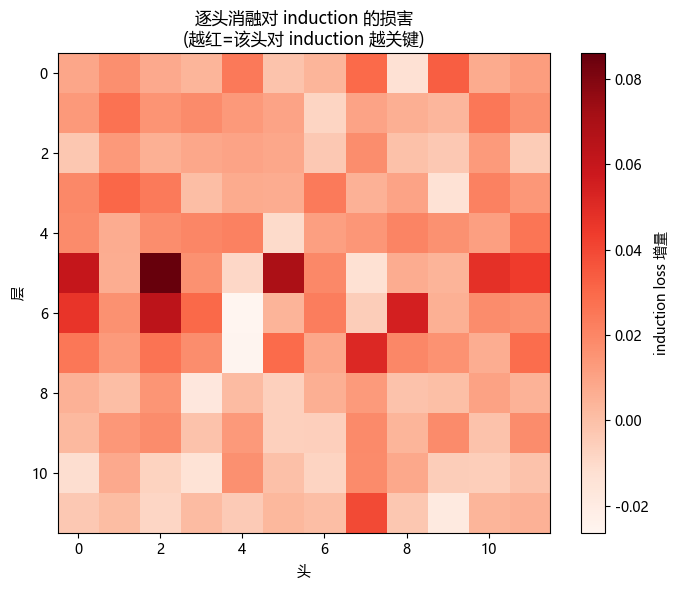

完整 induction loss = 0.303
对 induction 最关键的 top5 头 (层,头):
  层5 头2: 消融损害 +0.086
  层5 头5: 消融损害 +0.069
  层6 头2: 消融损害 +0.063
  层5 头0: 消融损害 +0.060
  层6 头8: 消融损害 +0.055
→ 多个头都亮 → induction 是一组头协作 (冗余 circuit), 不是单个头 (L3)。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
tok, model = rm.gpt2(output_attentions=True)
if model is not None:
    tokens, k = ci.make_repeated_tokens(tok, n_unique=20, seed=0)
    grid, base = ci.per_head_ablation(model, tokens, k)   # 逐头消融的 loss 增量
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(grid, cmap='Reds', aspect='auto')
    ax.set_xlabel('头'); ax.set_ylabel('层'); ax.set_title('逐头消融对 induction 的损害\n(越红=该头对 induction 越关键)')
    plt.colorbar(im, label='induction loss 增量'); plt.tight_layout(); plt.show()
    top = np.dstack(np.unravel_index(np.argsort(-grid, axis=None)[:5], grid.shape))[0]
    print(f'完整 induction loss = {base:.3f}')
    print('对 induction 最关键的 top5 头 (层,头):')
    for L,H in top:
        print(f'  层{L} 头{H}: 消融损害 {grid[L,H]:+.3f}')
    print('→ 多个头都亮 → induction 是一组头协作 (冗余 circuit), 不是单个头 (L3)。')
else:
    print('无 gpt2')

## 2. 整组 vs 单个: 冗余的证据

In [3]:
if model is not None:
    # 单头损害 vs 多头总损害对比
    single = grid.max()
    topk_sum = np.sort(grid, axis=None)[-3:].sum()
    print(f'单个最强头损害:     {single:+.3f}')
    print(f'top3 头损害之和:    {topk_sum:+.3f}')
    print(f'''
解读 (L3/L4):
  - 单头消融损害小 (冗余: 别的头能顶上)
  - 多头合起来贡献大 (induction 是一组头的协作)
  → 这就是为什么 circuit 分析要看「整组」而非单点 (单点消融会低估)
  → 归因 patching (L4) 用梯度一次性扫全部头, 看到整个 circuit 的分布''')

单个最强头损害:     +0.086
top3 头损害之和:    +0.218

解读 (L3/L4):
  - 单头消融损害小 (冗余: 别的头能顶上)
  - 多头合起来贡献大 (induction 是一组头的协作)
  → 这就是为什么 circuit 分析要看「整组」而非单点 (单点消融会低估)
  → 归因 patching (L4) 用梯度一次性扫全部头, 看到整个 circuit 的分布


## 3. 反思 (12.5 收口)

你画了 induction circuit 的组件分布 (逐头贡献)。带走:
- **逐头贡献热图**: 每个头对行为的因果贡献; 多个头亮 = 冗余 circuit。
- **冗余**: 单头消融损害小 (有备份), 整组贡献大 → circuit 分析要看整组 (L3)。
- **归因 patching** (L4): 梯度一次性估全部组件贡献, 规模化 (逐头消融的加速版)。

> **M12.5 收口**: head=QK+OV; induction head=ICL机制(真gpt2); circuit=组件+信息流; 冗余要看整组; 归因 patching 规模化。
> **交棒 M12.6「cot-faithfulness-oversight」**: interp 用到推理模型 — CoT 是真「内心独白」吗? 忠实性/监控/欺骗检测 (对齐安全前沿)。下一专题 `cot-faithfulness-oversight`。